In [46]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from sklearn.cluster import DBSCAN, HDBSCAN
import matplotlib.cm as cm
from matplotlib.colors import ListedColormap
import os
from sklearn.preprocessing import MinMaxScaler
import glob

In [47]:
df = pd.read_csv("datos_resultados_modularizado/hdbscan_ra180_dec-30_prev.csv")
df = df.sort_values(by=['source_id','ConteoAgrupaciones'], ascending=[False,False]).drop_duplicates(subset=['source_id'], keep='first')
df['probabilidad'] = df['ConteoAgrupaciones']/(df['iteraciones']*10)
df = df[df['probabilidad']>0.5]

In [48]:
df['parallax_over_error'] = abs(df['parallax']/df['parallax_error'])
df['parallax_relative_error'] = 1/df['parallax_over_error']*100
df['pmra_over_error'] = abs(df['pmra']/df['pmra_error'])
df['pmra_relative_error'] = 1/df['pmra_over_error']*100
df['pmdec_over_error'] = abs(df['pmdec']/df['pmdec_error'])
df['pmdec_relative_error'] = 1/df['pmdec_over_error']*100
df['ra_over_error'] = abs(df['ra']/df['ra_error'])
df['ra_relative_error'] = 1/df['ra_over_error']*100
df['dec_over_error'] = abs(df['dec']/df['dec_error'])
df['dec_relative_error'] = 1/df['dec_over_error']*100
# len(df[df['relative_error']>df['relative_error'].quantile(0.75) +((df['relative_error'].quantile(0.75)-df['relative_error'].quantile(0.25))/2)])

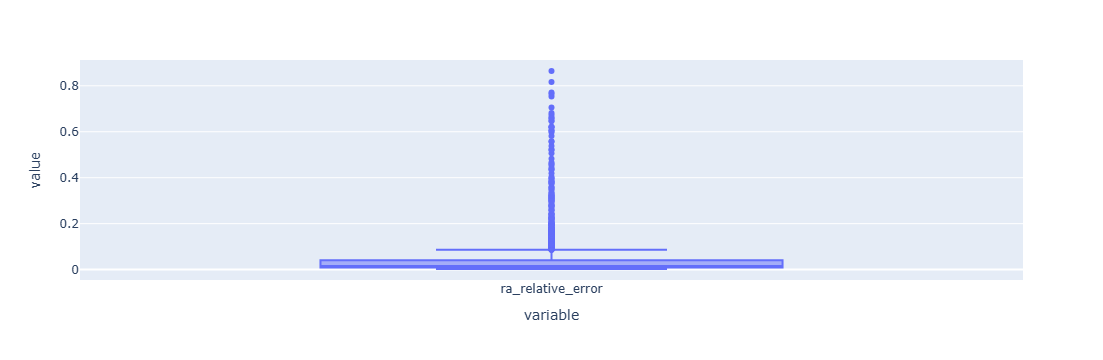

In [49]:
px.box(df['ra_relative_error'])

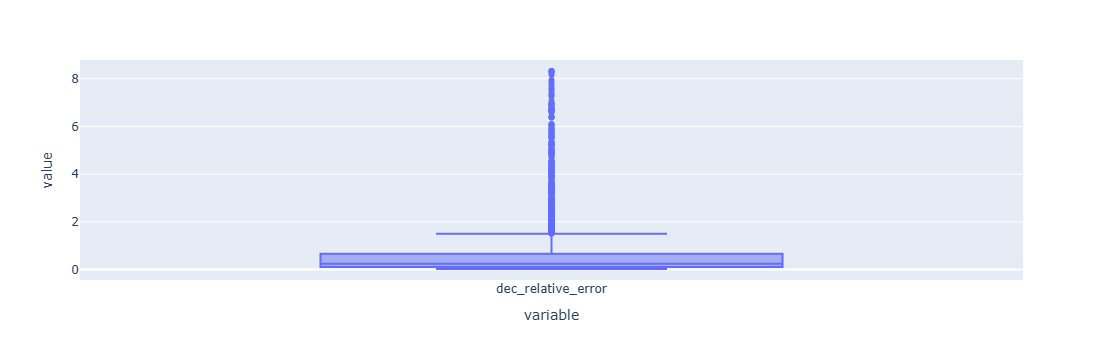

In [50]:
px.box(df['dec_relative_error'])

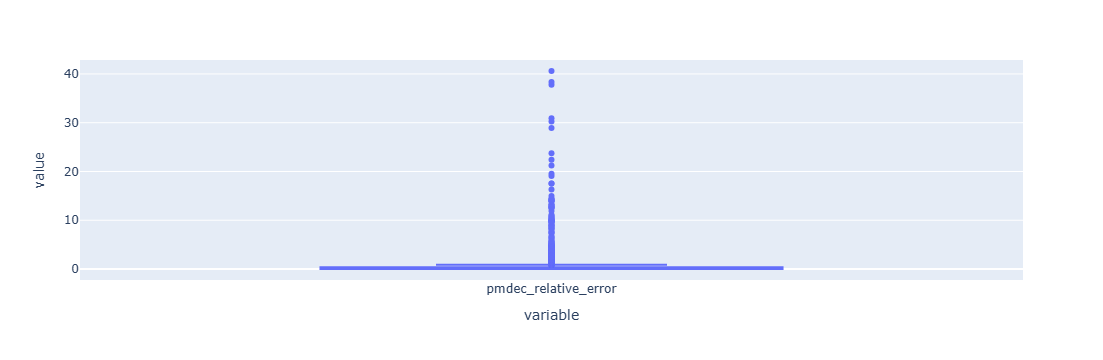

In [51]:
px.box(df['pmdec_relative_error'])

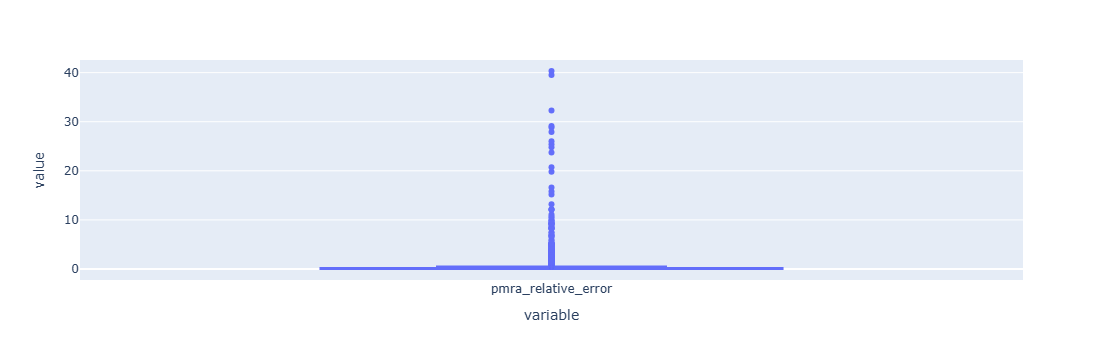

In [52]:
px.box(df['pmra_relative_error'])

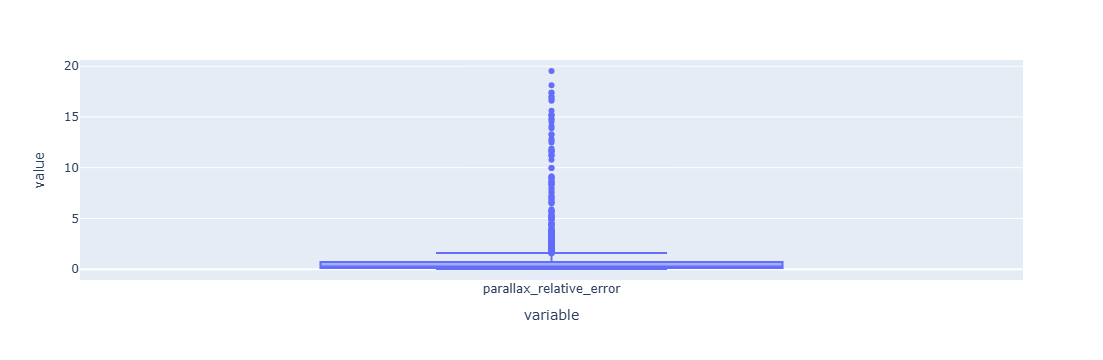

In [53]:
px.box(df['parallax_relative_error'])

(array([1954.,  147.,   37.,   20.,   13.,    8.,    8.,   10.,    4.,
           2.]),
 array([0.00267395, 0.088852  , 0.17503005, 0.2612081 , 0.34738615,
        0.4335642 , 0.51974225, 0.6059203 , 0.69209834, 0.77827639,
        0.86445444]),
 <BarContainer object of 10 artists>)

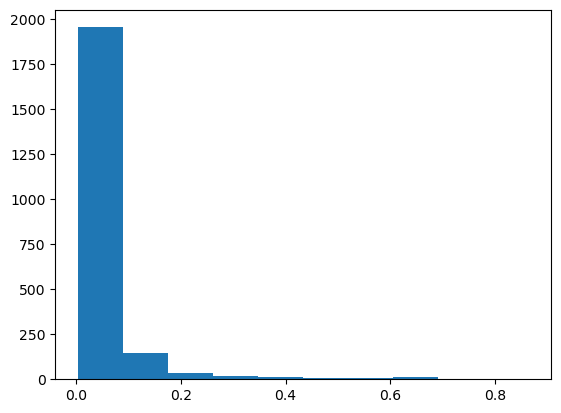

In [54]:
plt.hist(df['ra_relative_error'])

(array([1.188e+03, 1.140e+02, 1.570e+02, 7.100e+01, 1.930e+02, 1.030e+02,
        6.600e+01, 5.500e+01, 3.800e+01, 3.000e+01, 3.100e+01, 1.300e+01,
        1.700e+01, 1.100e+01, 1.400e+01, 7.000e+00, 3.000e+00, 1.000e+01,
        7.000e+00, 3.000e+00, 0.000e+00, 2.000e+00, 2.000e+00, 1.000e+00,
        3.000e+00, 2.000e+00, 0.000e+00, 1.000e+00, 0.000e+00, 1.000e+00,
        0.000e+00, 1.000e+00, 2.000e+00, 2.000e+00, 0.000e+00, 0.000e+00,
        1.000e+00, 0.000e+00, 0.000e+00, 1.000e+00, 0.000e+00, 0.000e+00,
        0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
        1.000e+00, 1.000e+00]),
 array([ 10.00042007,  14.42278162,  18.84514318,  23.26750473,
         27.68986629,  32.11222784,  36.5345894 ,  40.95695095,
         45.37931251,  49.80167406,  54.22403561,  58.64639717,
         63.06875872,  67.49112028,  71.91348183,  76.33584339,
         80.75820494,  85.1805665 ,  89.60292805,  94.02528961,
         98.44765116, 102.87001272, 107.29237427, 111.71

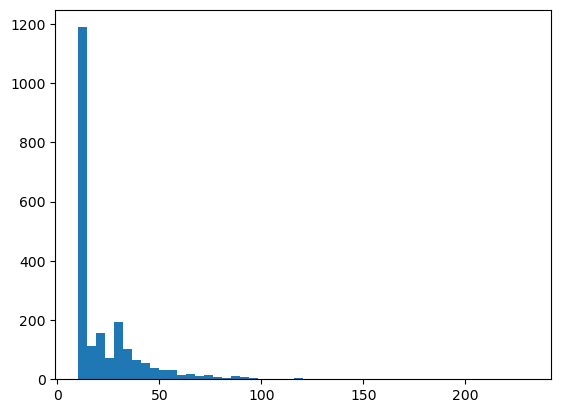

In [55]:

plt.hist(df[df['parallax_relative_error']<=7]['parallax'], bins=50)

(0.0, 7.0)

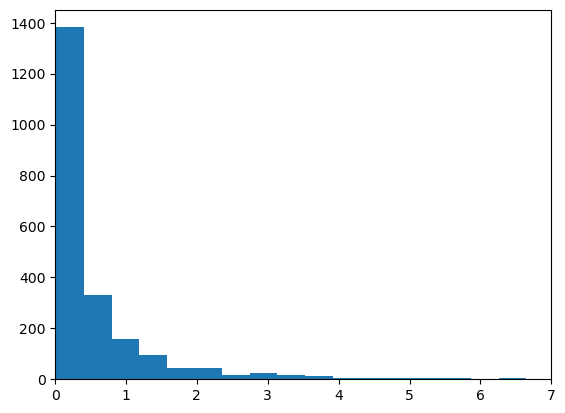

In [56]:
plt.hist(df['parallax_relative_error'], bins=50)
plt.xlim(0,7)

In [57]:
# df['probabilidad'] = MinMaxScaler().fit_transform(df['ConteoAgrupaciones'].values.reshape(-1, 1))
# df = df[df['probabilidad']>0.5]

In [58]:
# definicion de parametros y modelo a ejecutar
min_pts = 20
max_pts = 1500

hdbscan = HDBSCAN(min_cluster_size=min_pts, max_cluster_size=max_pts)
hdbscan.fit(df[['pmra_norm', 'pmdec_norm', 'parallax_norm']])
etiquetas = hdbscan.labels_
df['cluster'] = etiquetas
np.unique(etiquetas, return_counts=True)

# Paso 1: Calcular el tamaño de cada cluster
top_clusters = df['cluster'].value_counts().nlargest(50).index

# Paso 2: Filtrar el DataFrame con esos clusters
dff = df[df['cluster'].isin(top_clusters)].copy()

# listado de clusters generados
clusters = np.sort(dff['cluster'].unique())
# Crear un colormap con tantos colores como clusters
colormap = cm.get_cmap('Set1', len(top_clusters))  # o 'tab20', 'nipy_spectral', etc.

# Crear un diccionario de colores para cada cluster
color_dict = {cluster: colormap(i) for i, cluster in enumerate(top_clusters)}

# Asignar el color correspondiente a cada fila
dff['color'] = dff['cluster'].map(color_dict)

C:\Users\nicob\AppData\Local\Temp\ipykernel_18352\2997165423.py:20: MatplotlibDeprecationWarning:

The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.



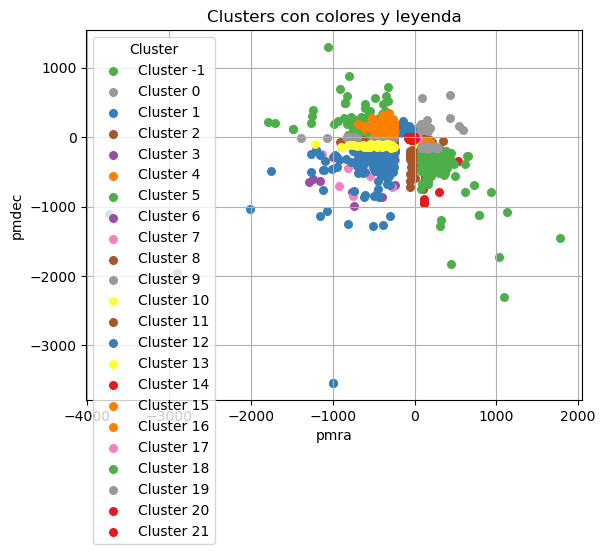

In [59]:
# Dibujar cada cluster por separado para asignar label
for cluster in clusters:
    subset = dff[dff['cluster'] == cluster]
    plt.scatter(subset['pmra'], subset['pmdec'],
                color=[color_dict[cluster]],
                label=f'Cluster {cluster}', s=30)

plt.xlabel('pmra')
plt.ylabel('pmdec')
plt.title('Clusters con colores y leyenda')
plt.legend(title='Cluster')
plt.grid(True)
plt.show()

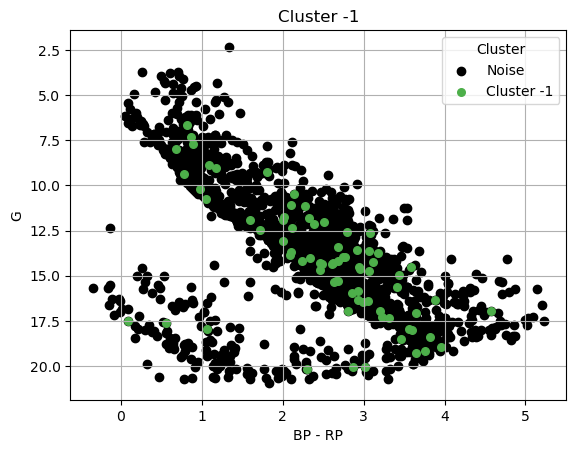

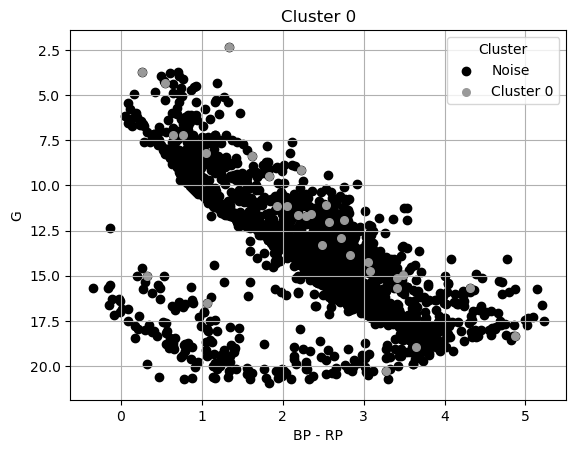

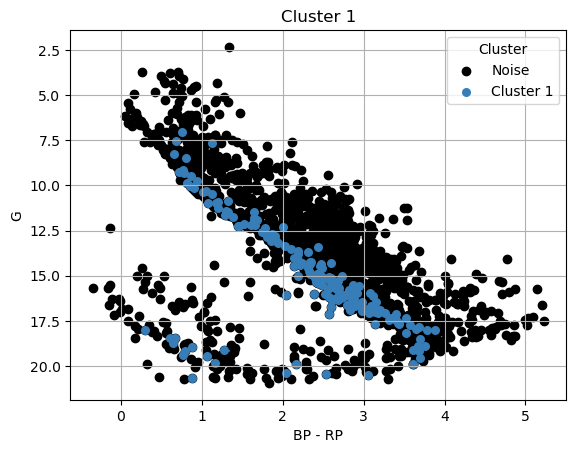

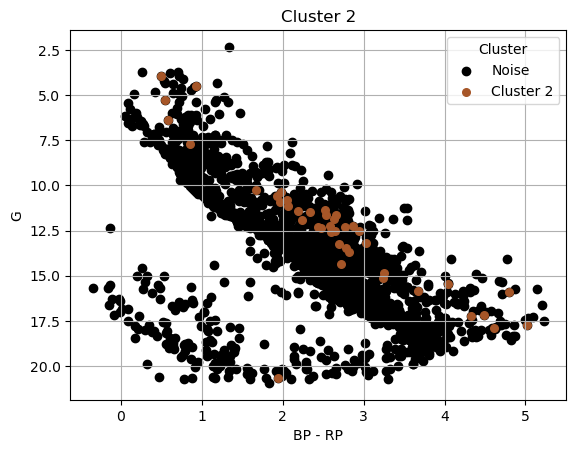

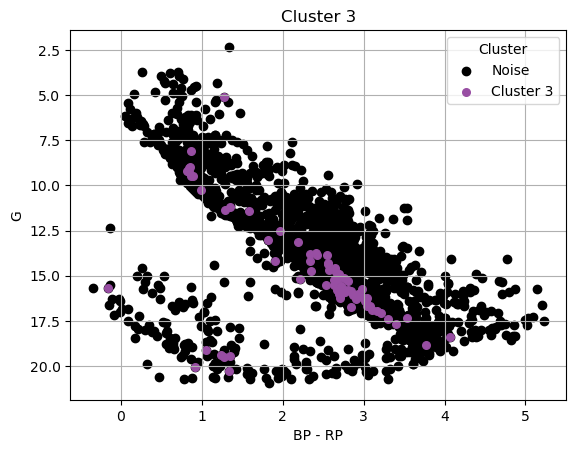

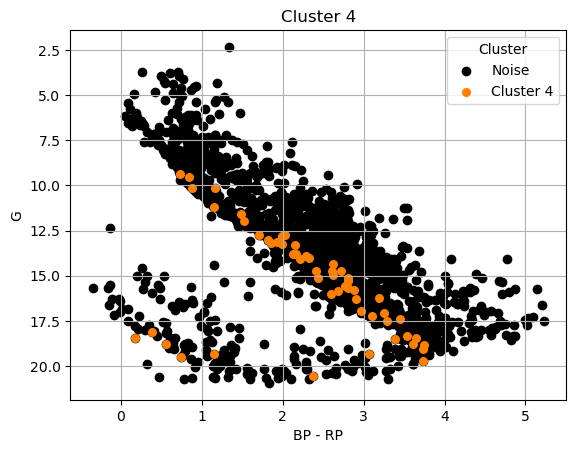

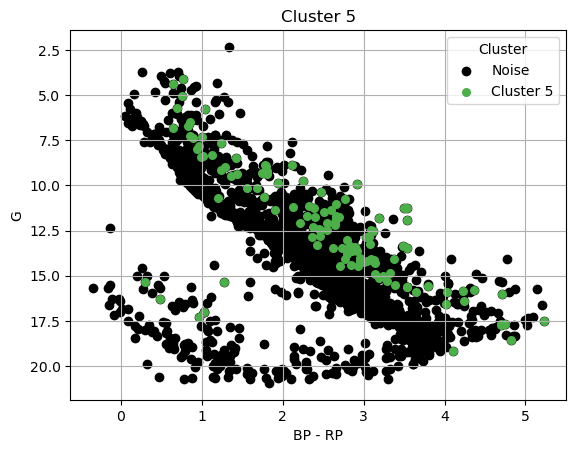

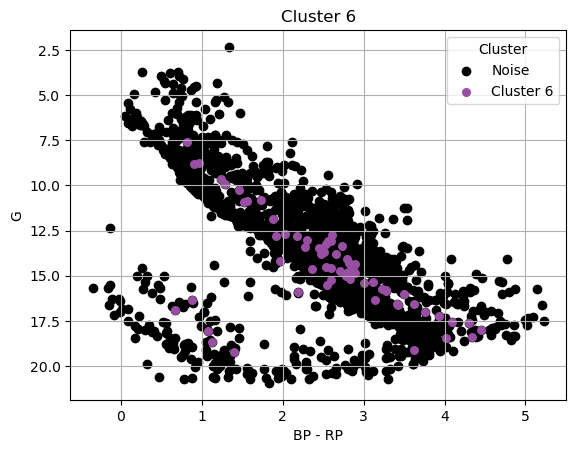

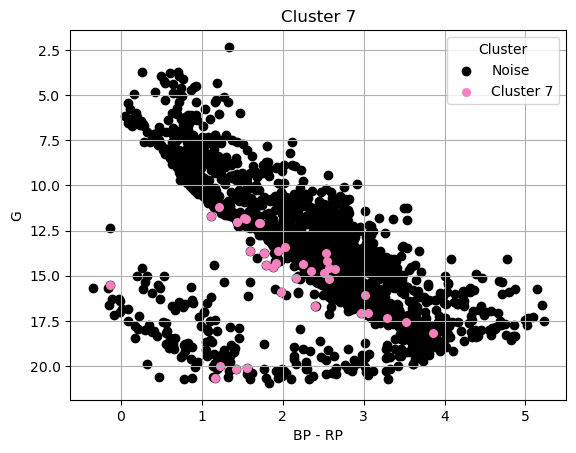

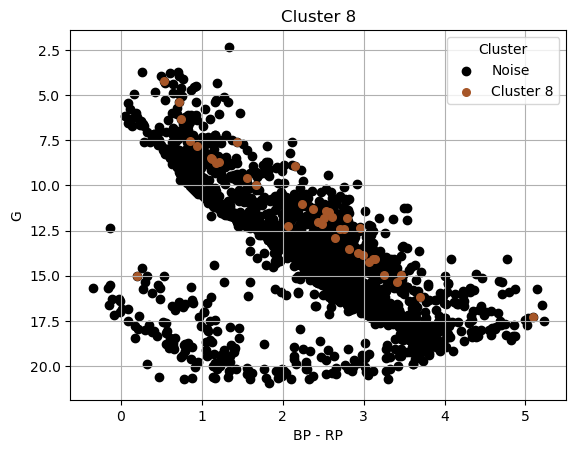

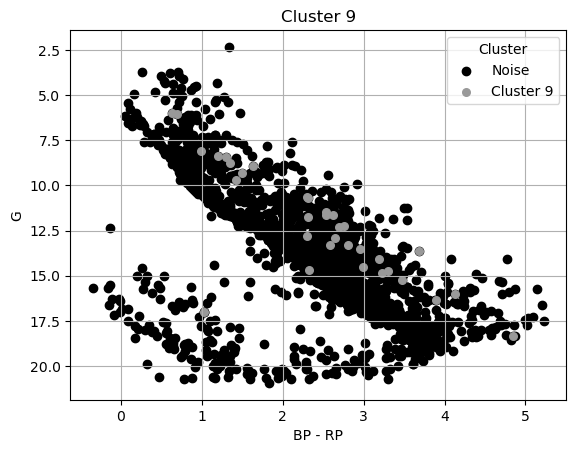

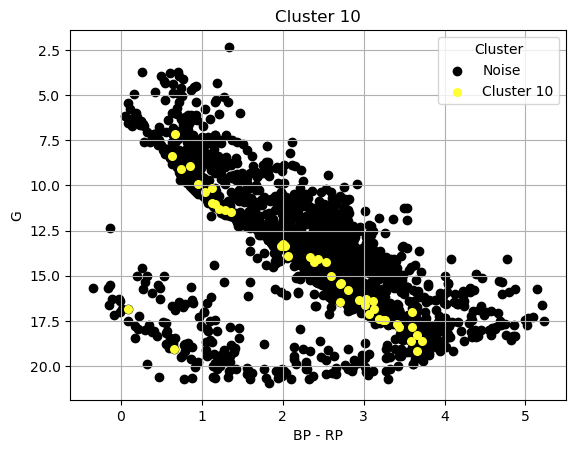

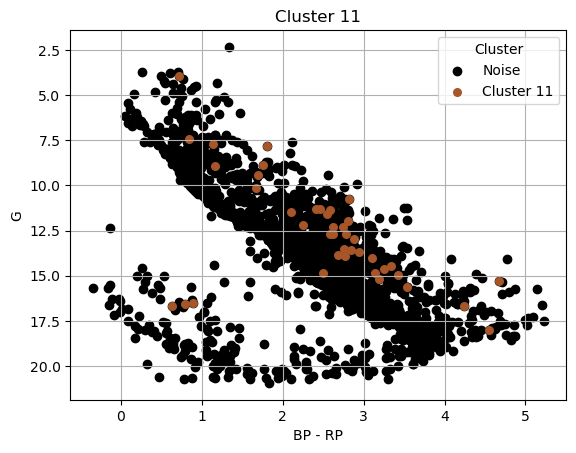

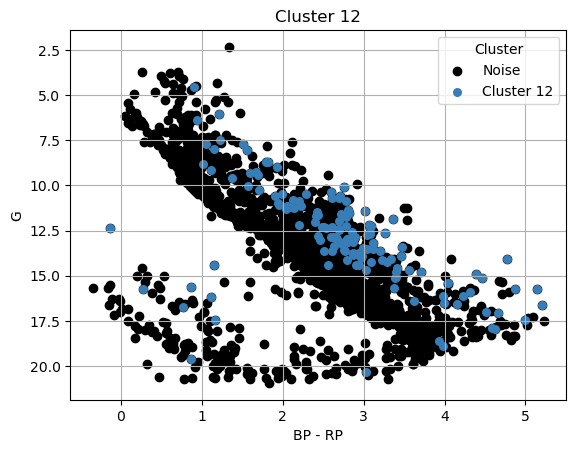

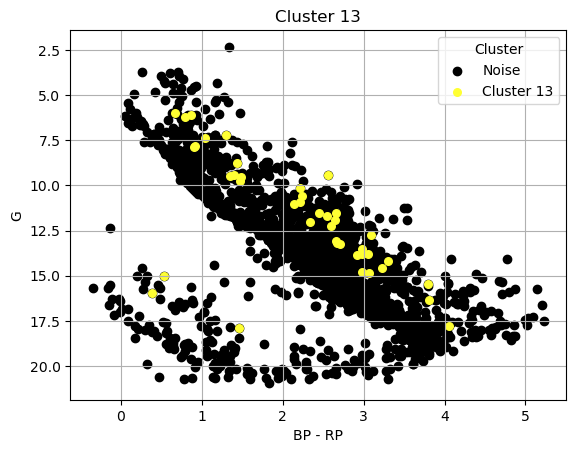

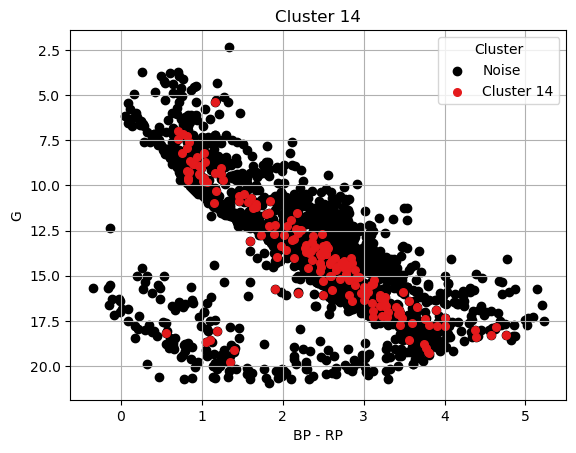

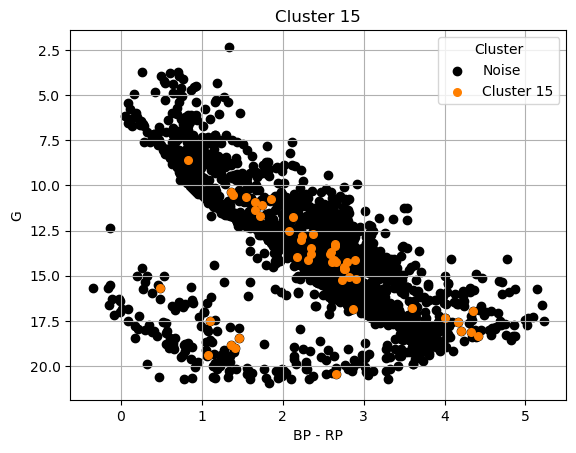

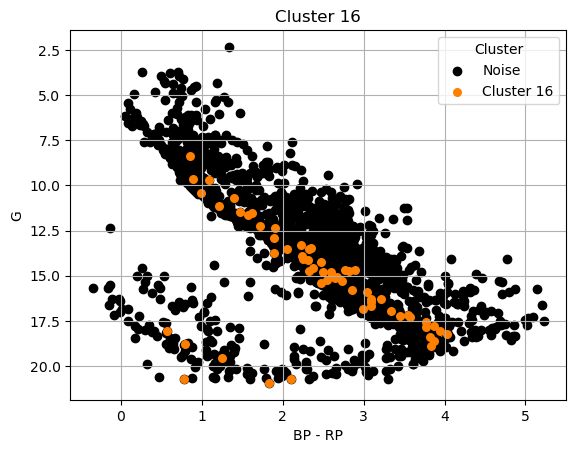

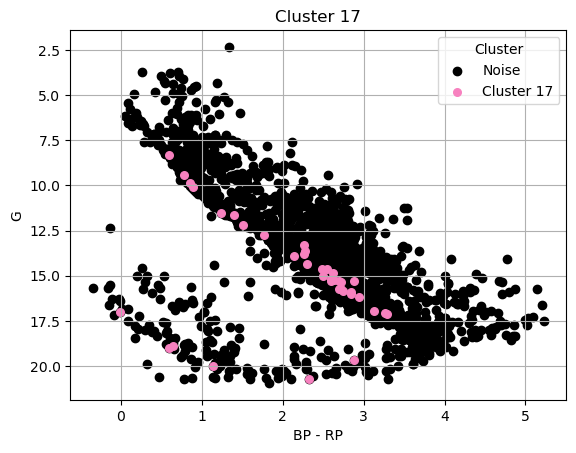

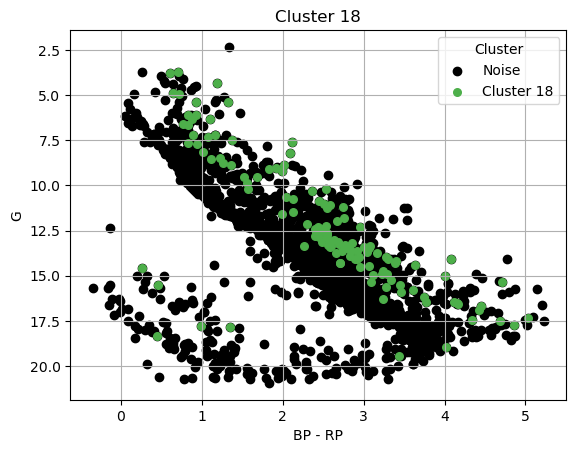

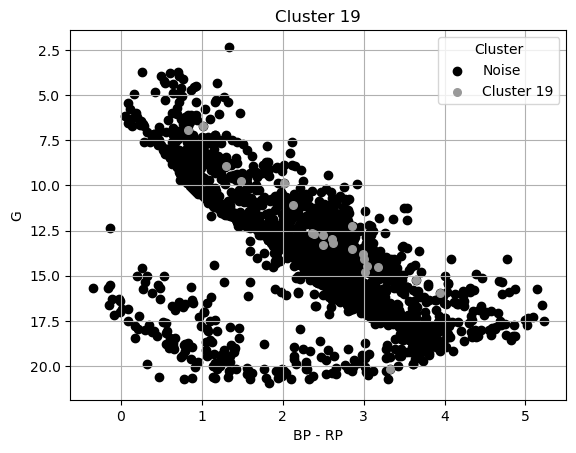

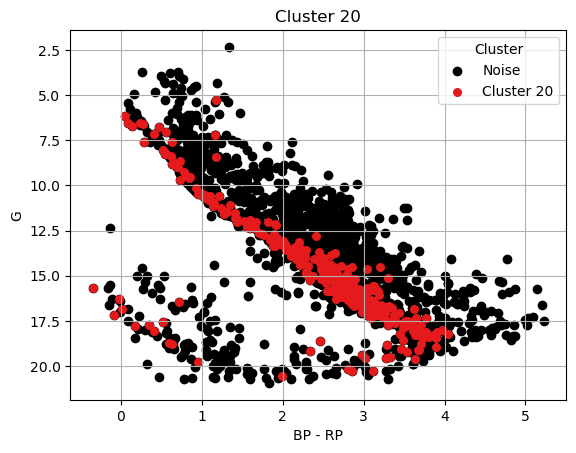

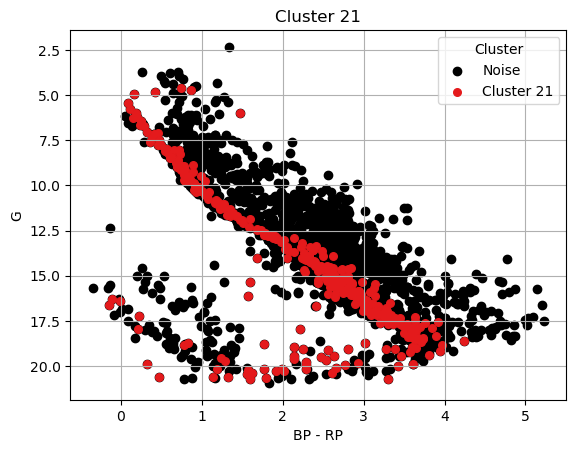

In [60]:
for cluster in clusters:
    subset = dff[dff['cluster'] == cluster]
    plt.scatter(dff['bp_rp'],dff['phot_g_mean_mag'], color='k', label='Noise')
    plt.scatter(subset['bp_rp'], subset['phot_g_mean_mag'],
                color=[color_dict[cluster]],
                label=f'Cluster {cluster}', s=30)

    plt.xlabel("BP - RP")
    plt.ylabel("G")

    plt.title(f'Cluster {cluster}')
    plt.legend(title='Cluster')
    plt.gca().invert_yaxis()
    plt.grid(True)
#     plt.savefig(f"ruta_imagenes_evolucion/diagramas_cm/diagrama_cluster_{cluster}.png")
    plt.show()

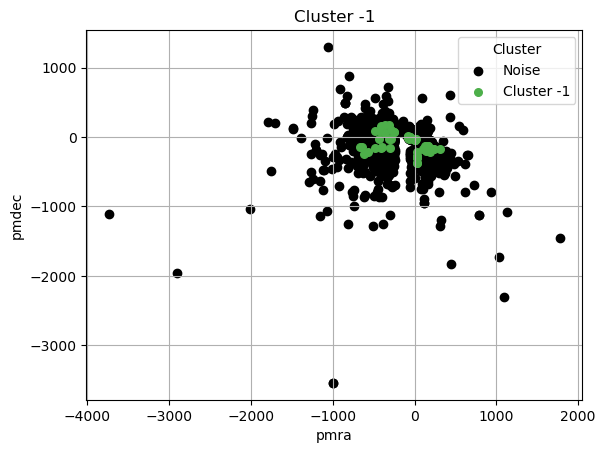

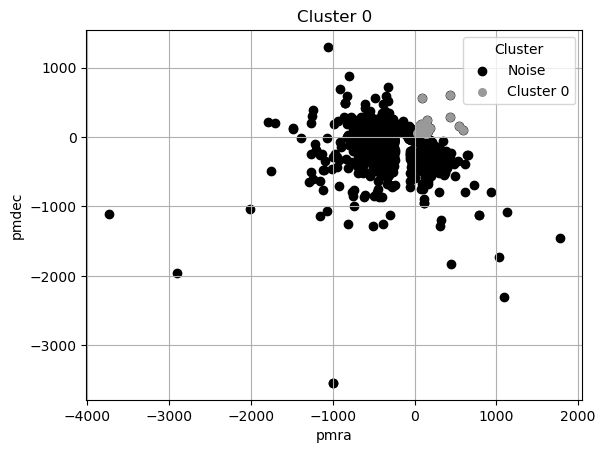

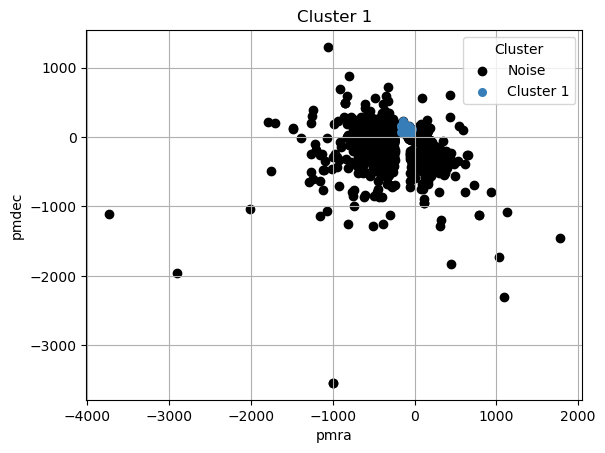

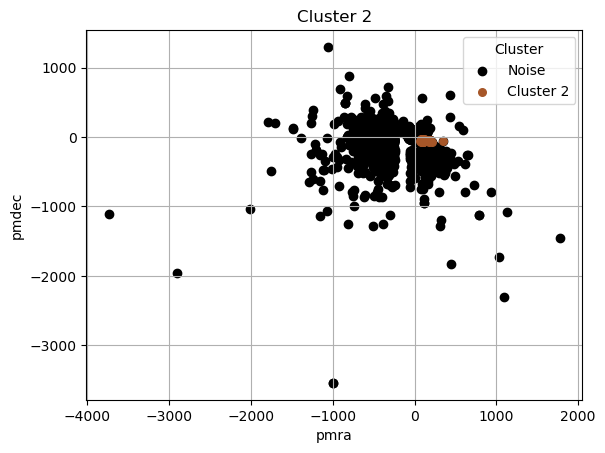

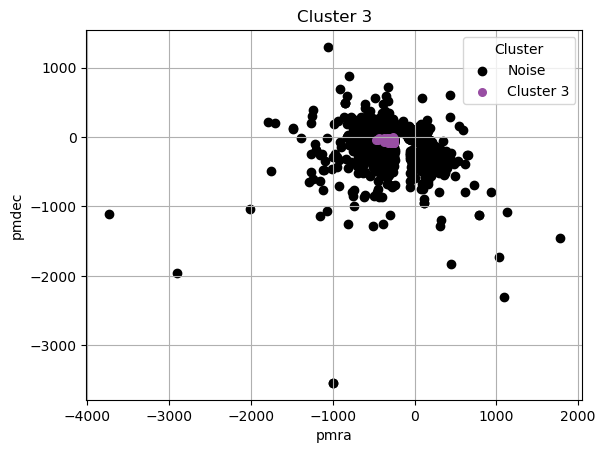

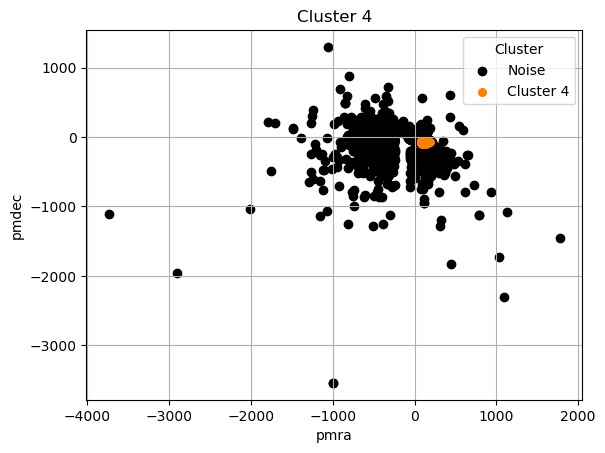

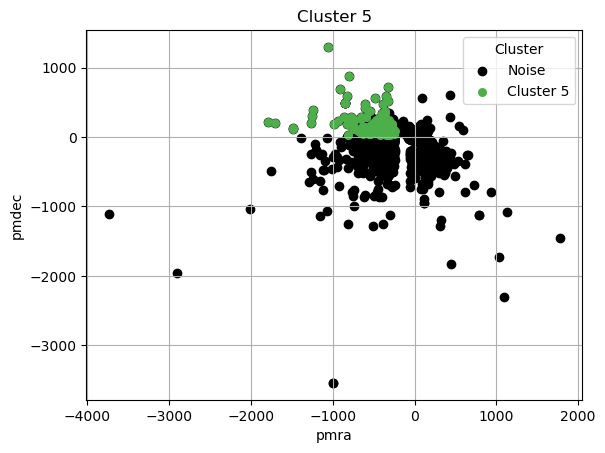

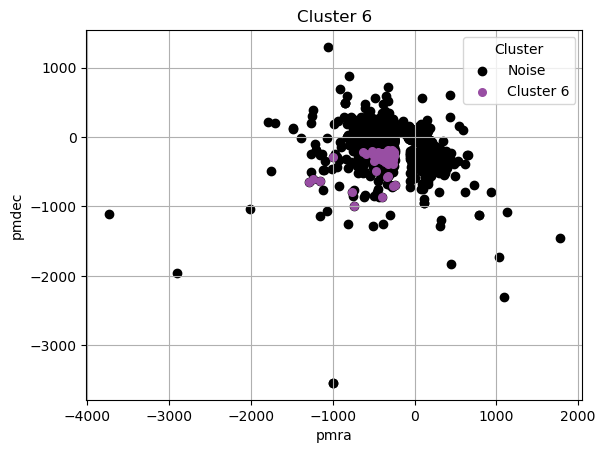

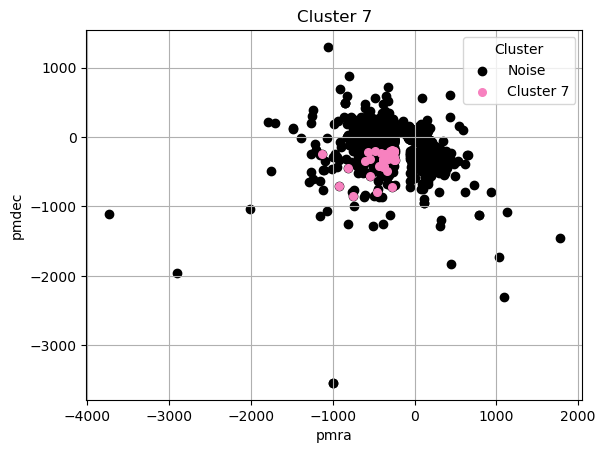

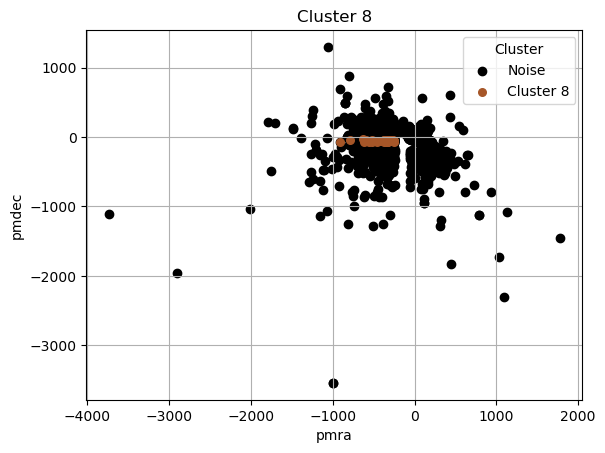

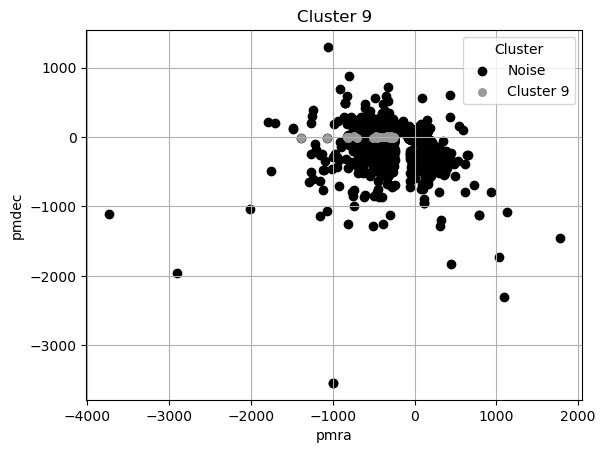

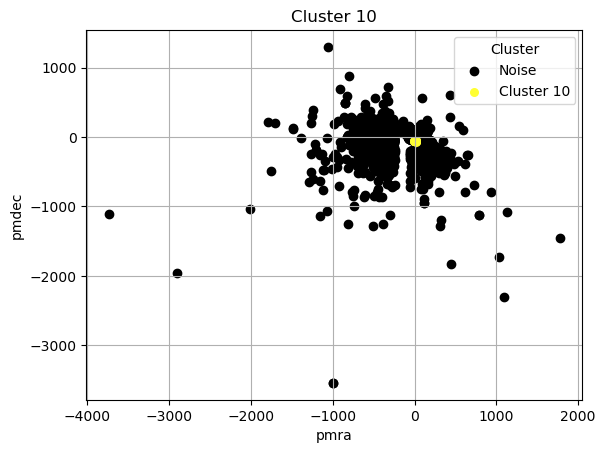

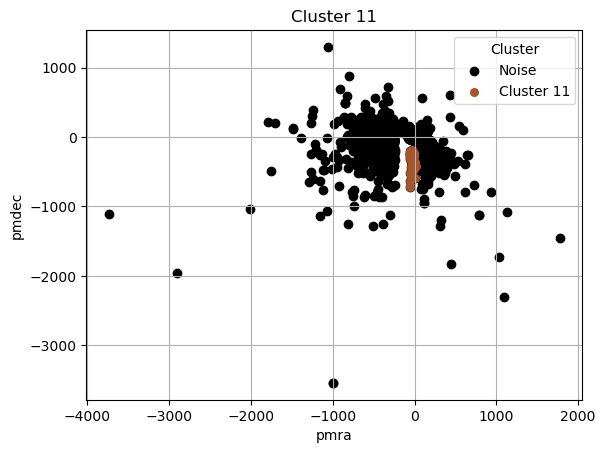

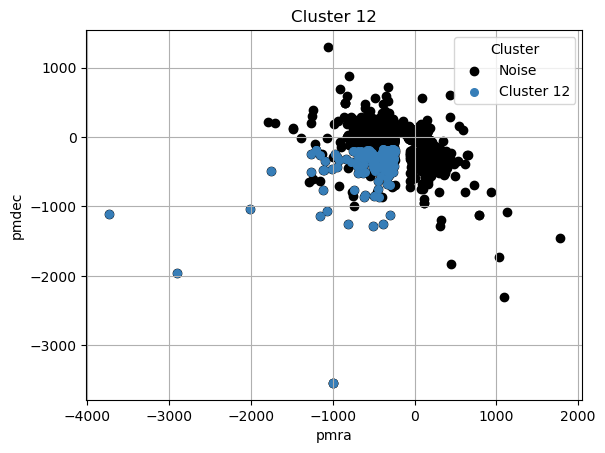

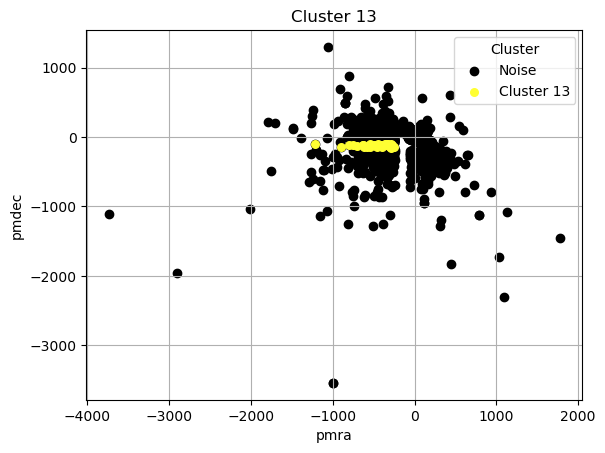

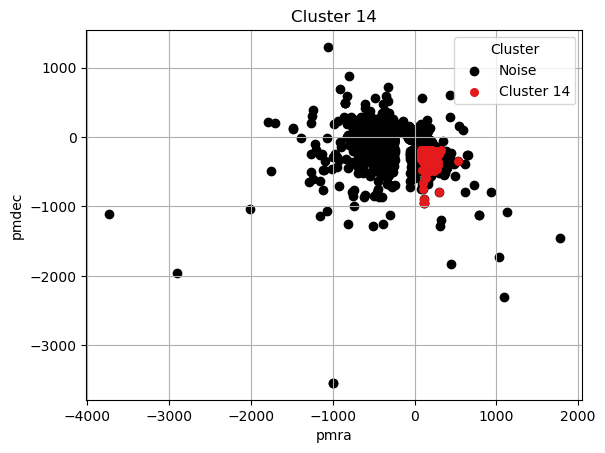

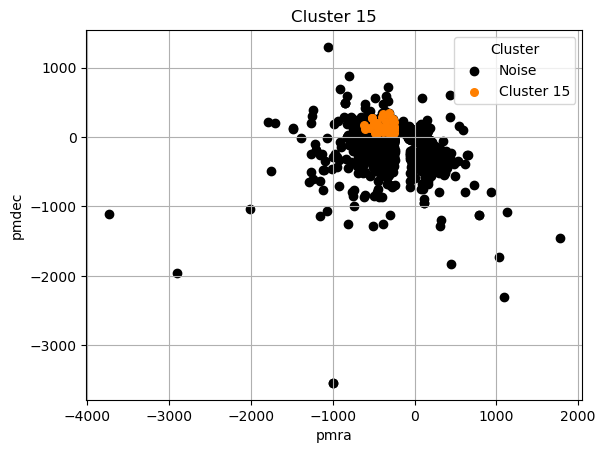

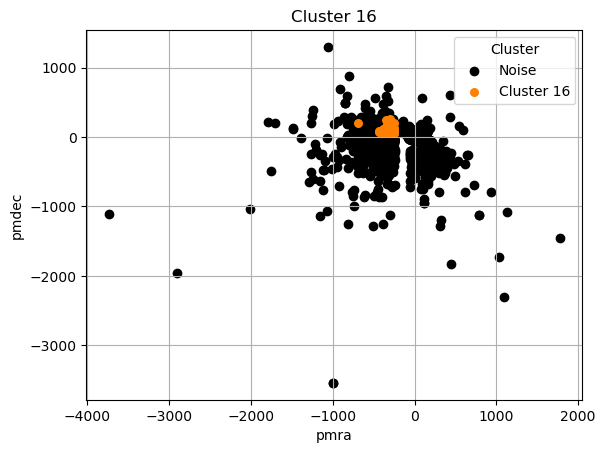

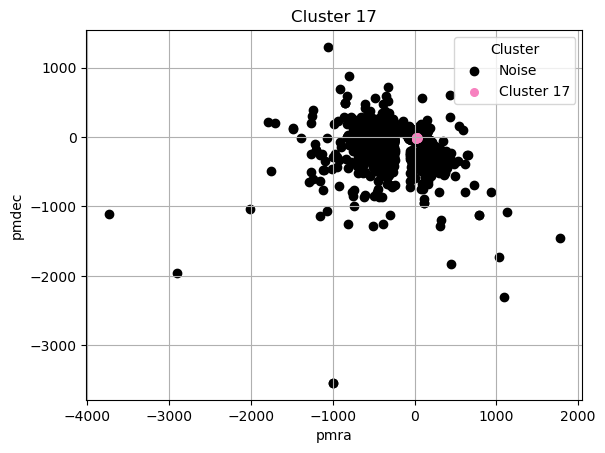

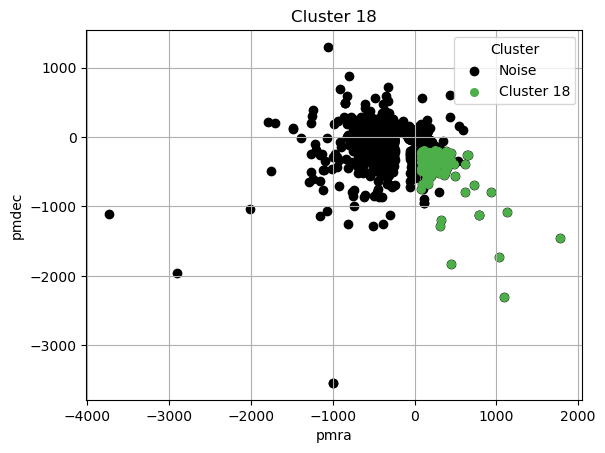

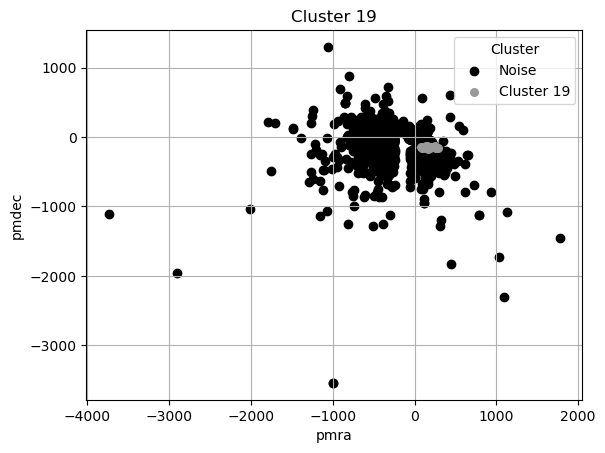

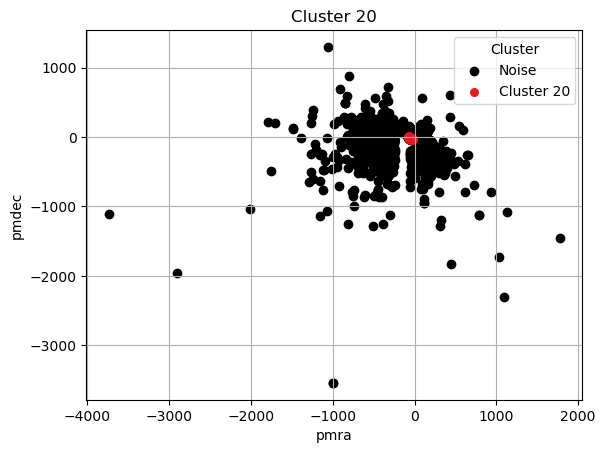

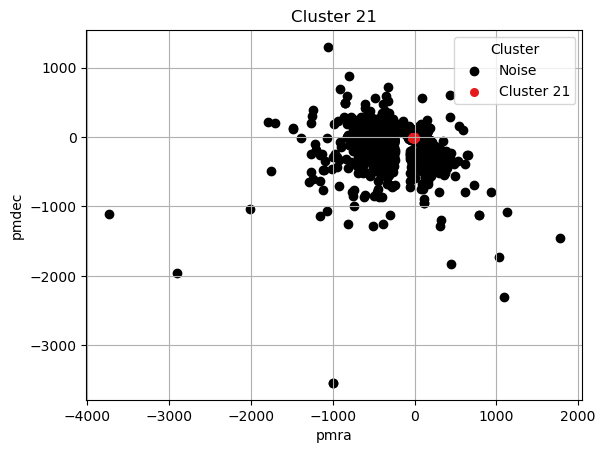

In [61]:
for cluster in clusters:
    subset = dff[dff['cluster'] == cluster]
    plt.scatter(df['pmra'],df['pmdec'], color='k', label='Noise')
    plt.scatter(subset['pmra'], subset['pmdec'],
                color=[color_dict[cluster]],
                label=f'Cluster {cluster}', s=30)

    plt.xlabel('pmra')
    plt.ylabel('pmdec')
    plt.title(f'Cluster {cluster}')
    plt.legend(title='Cluster')
    plt.grid(True)
#     plt.savefig(f"ruta_imagenes_evolucion/diagramas_cm/diagrama_cluster_{cluster}.png")
    plt.show()

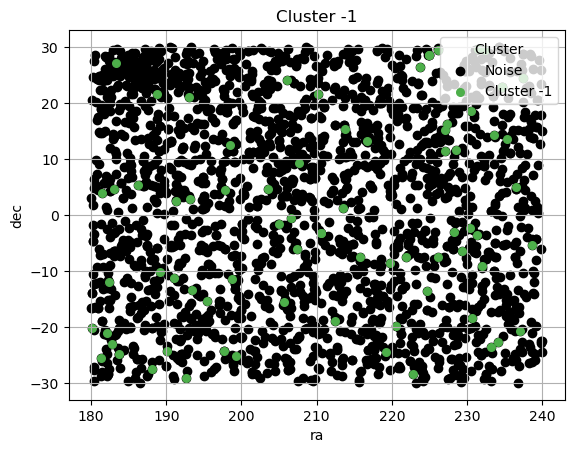

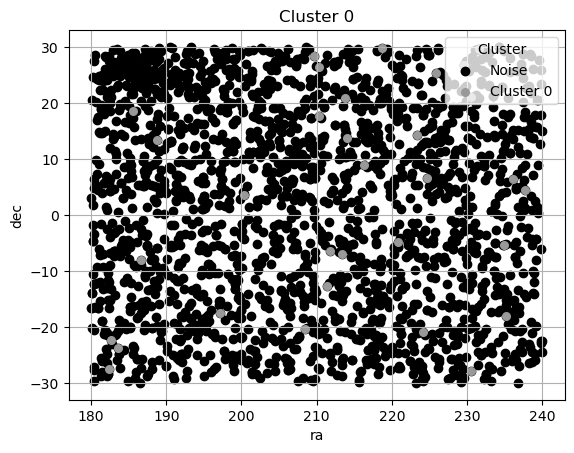

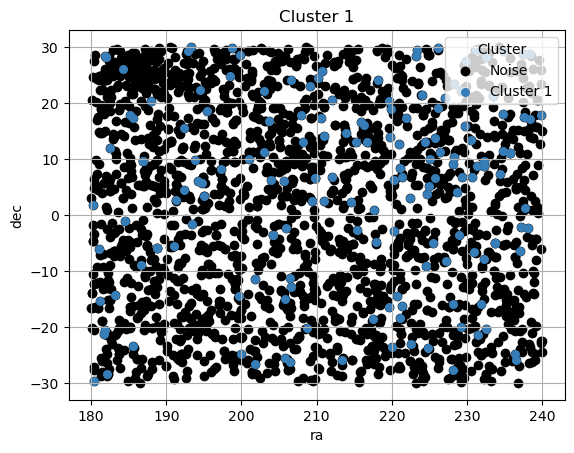

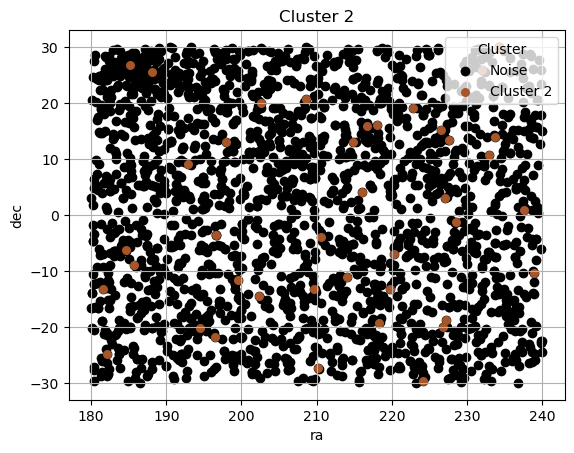

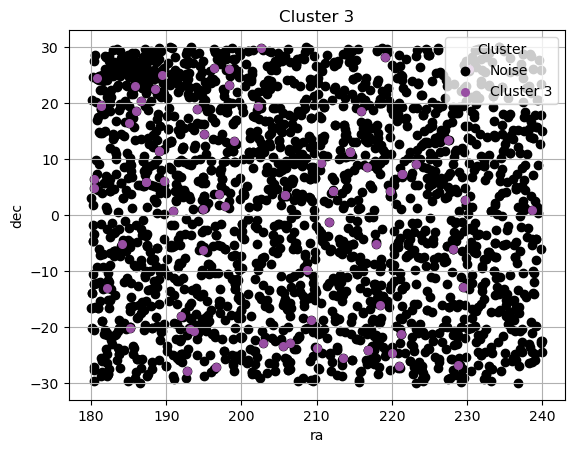

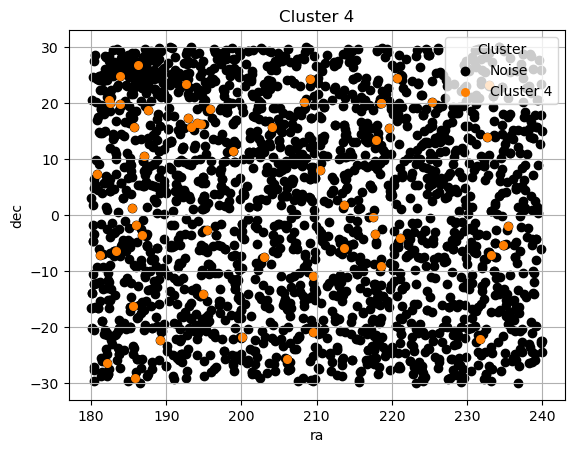

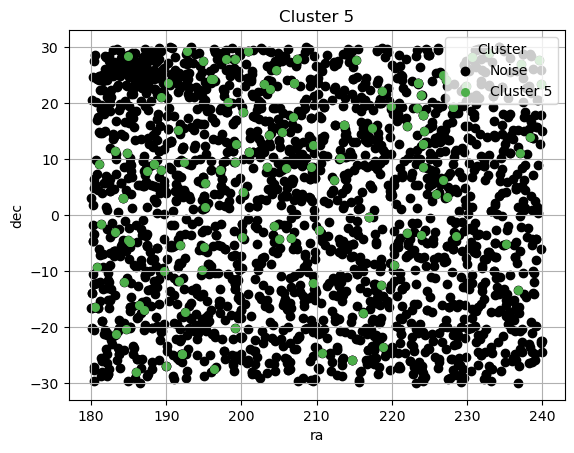

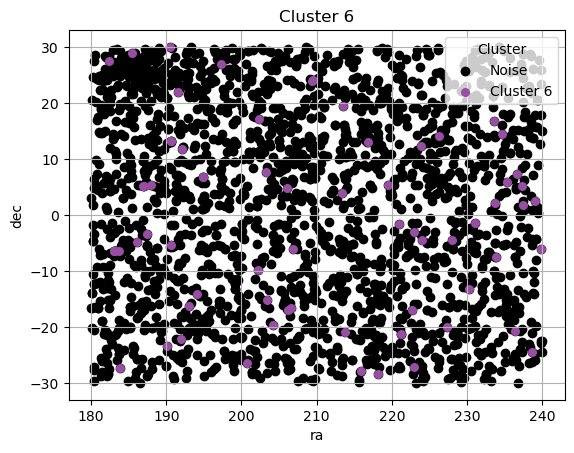

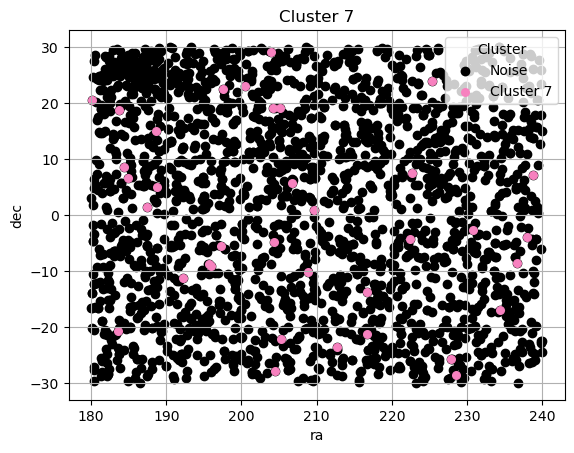

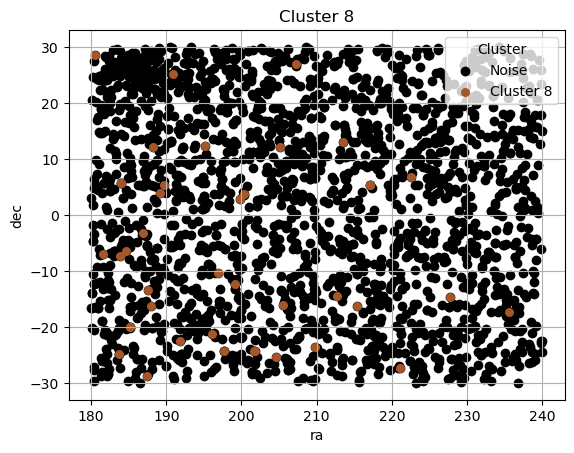

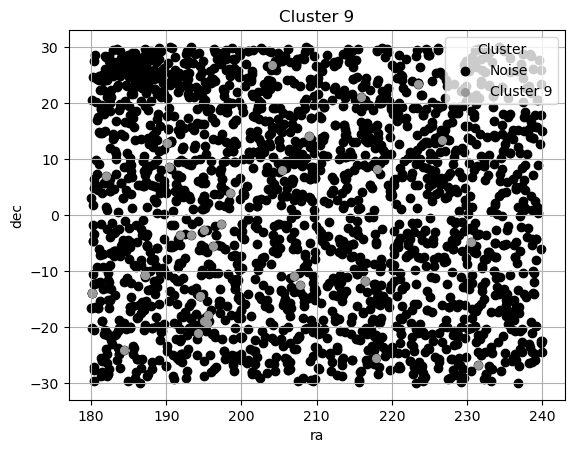

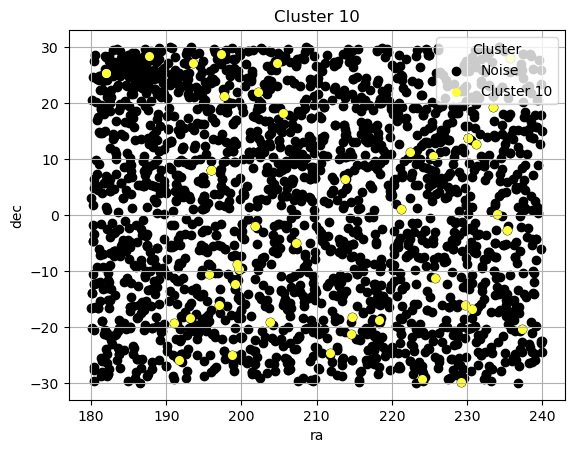

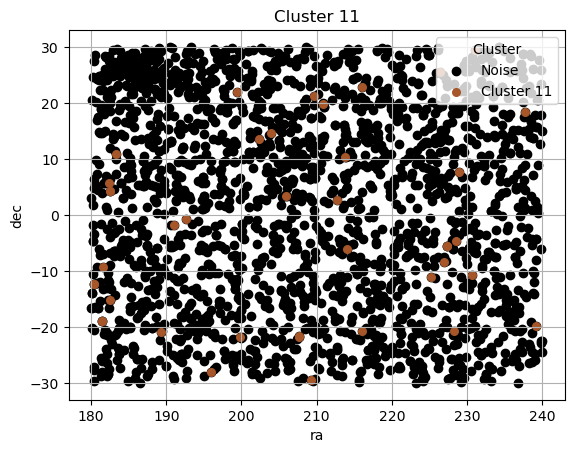

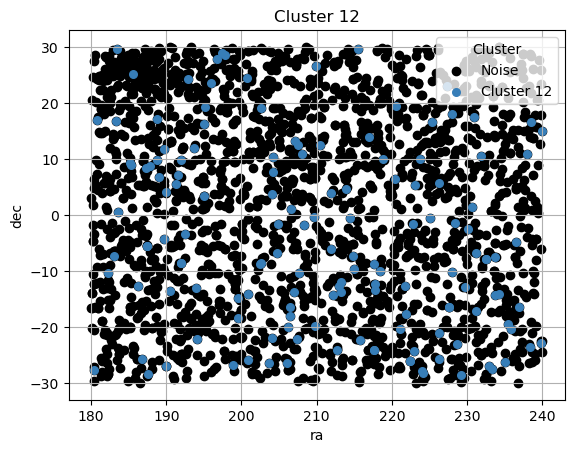

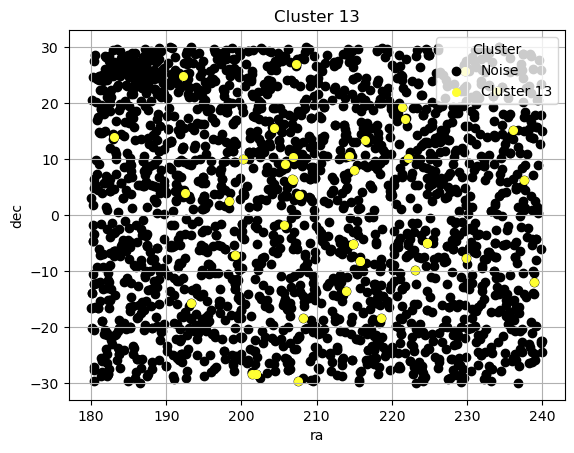

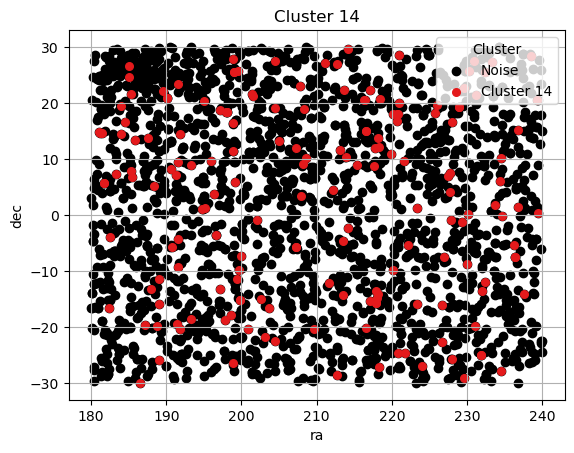

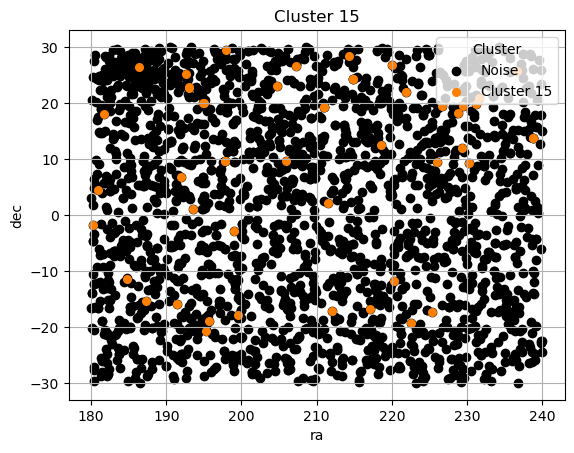

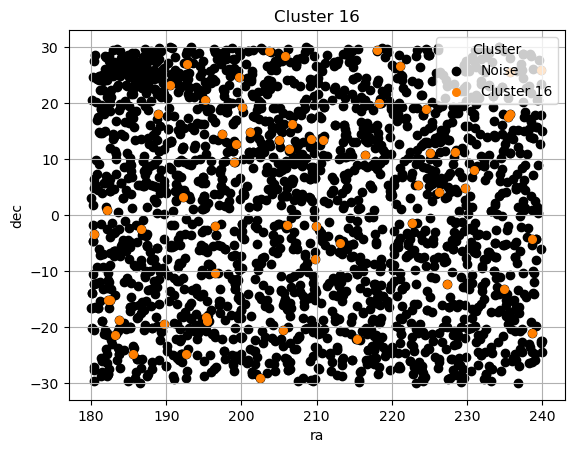

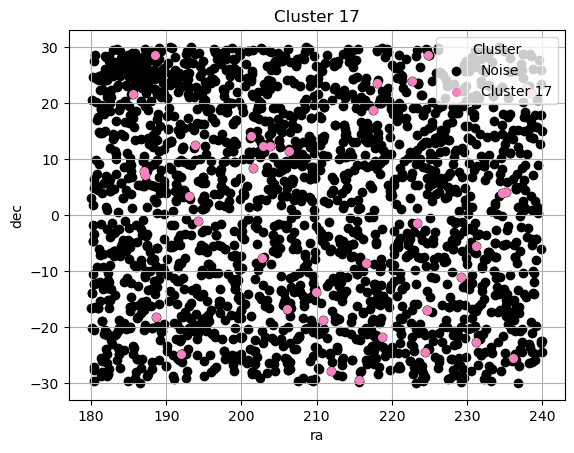

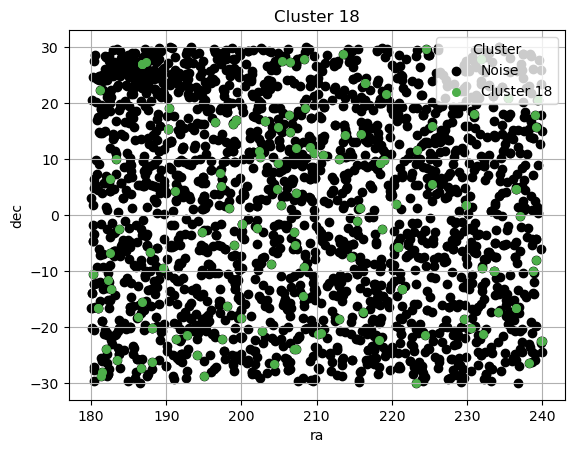

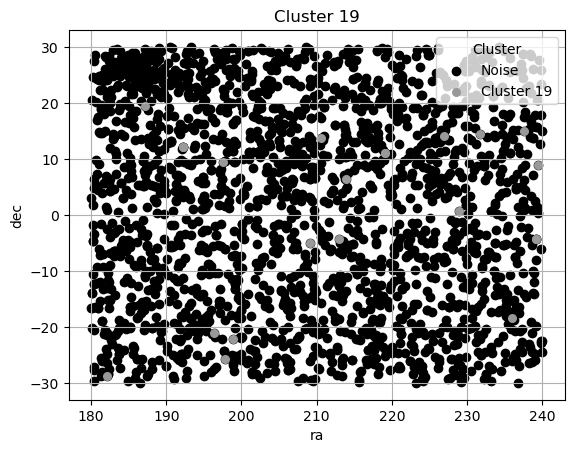

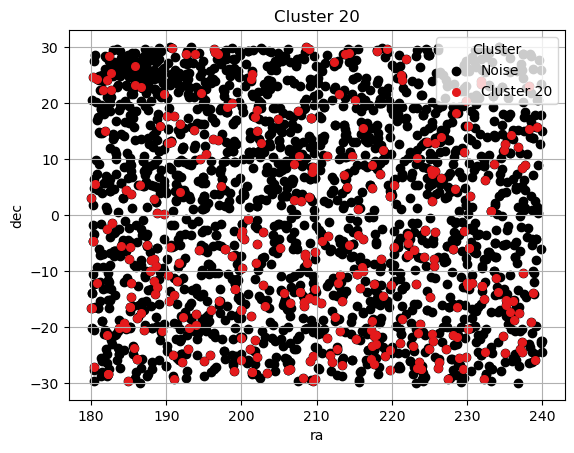

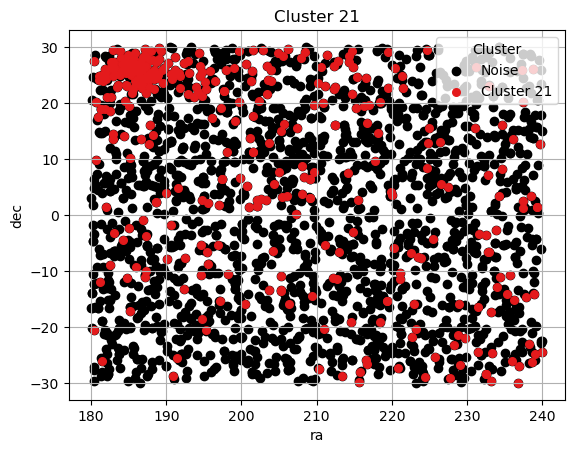

In [62]:
for cluster in clusters:
    subset = dff[dff['cluster'] == cluster]
    plt.scatter(df['ra'],df['dec'], color='k', label='Noise')
    plt.scatter(subset['ra'], subset['dec'],
                color=[color_dict[cluster]],
                label=f'Cluster {cluster}', s=30)

    plt.xlabel('ra')
    plt.ylabel('dec')
    plt.title(f'Cluster {cluster}')
    plt.legend(title='Cluster')
    plt.grid(True)
#     plt.savefig(f"ruta_imagenes_evolucion/diagramas_cm/diagrama_cluster_{cluster}.png")
    plt.show()

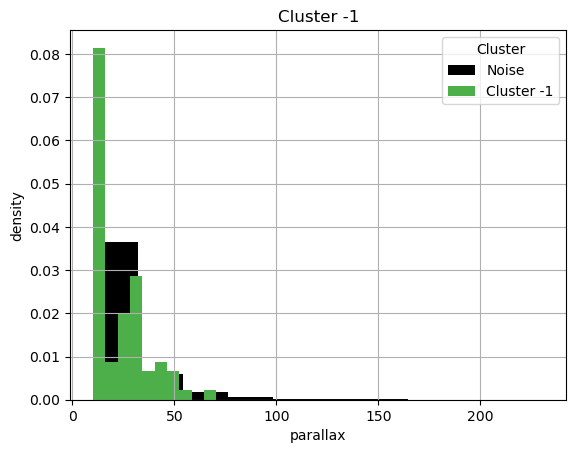

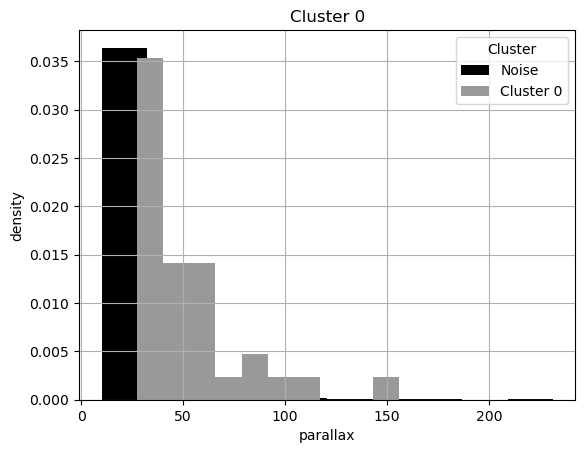

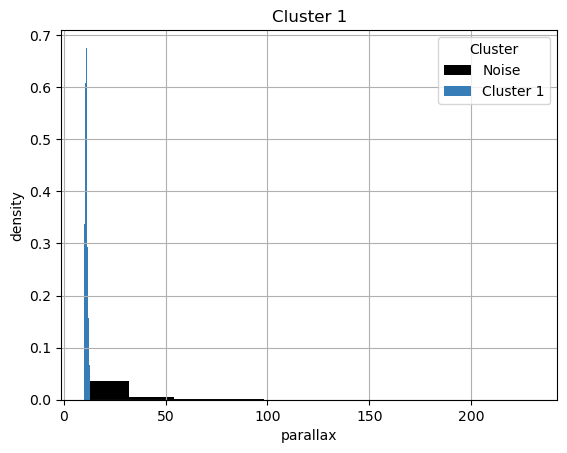

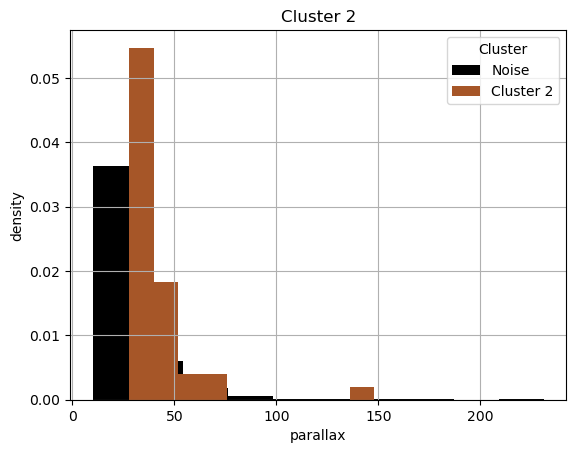

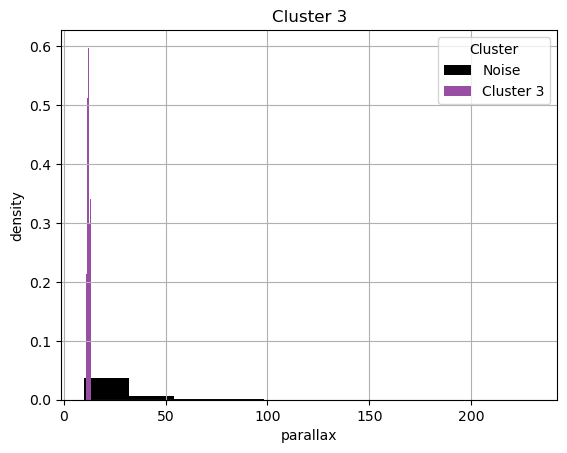

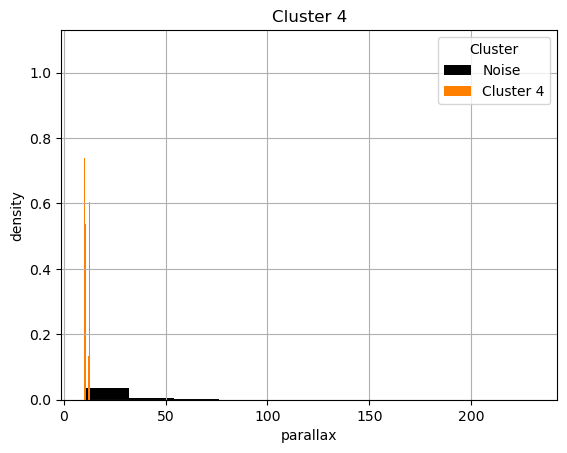

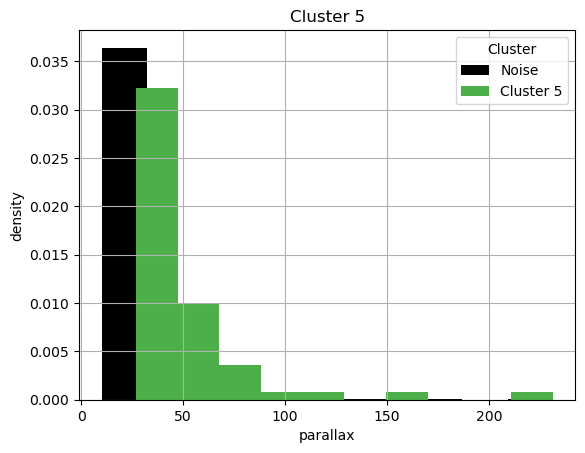

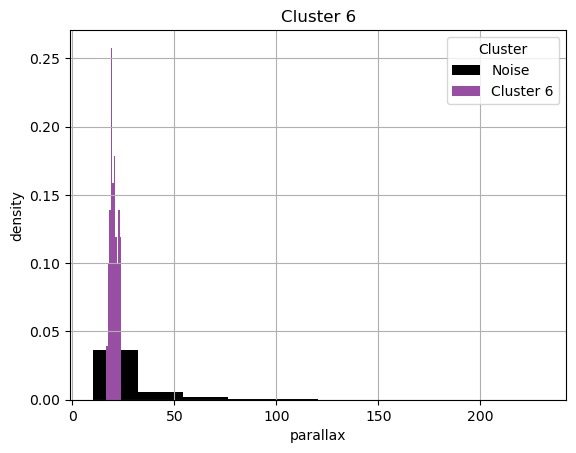

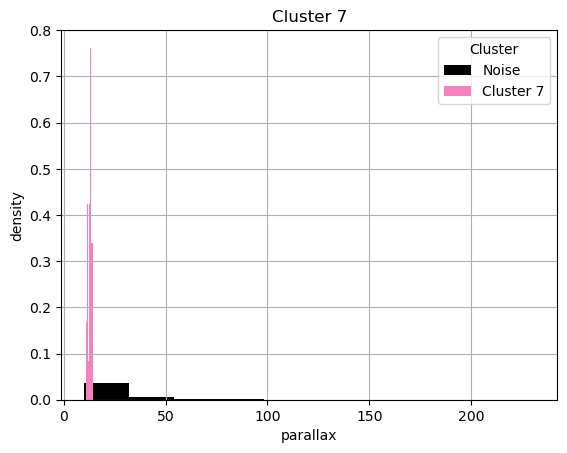

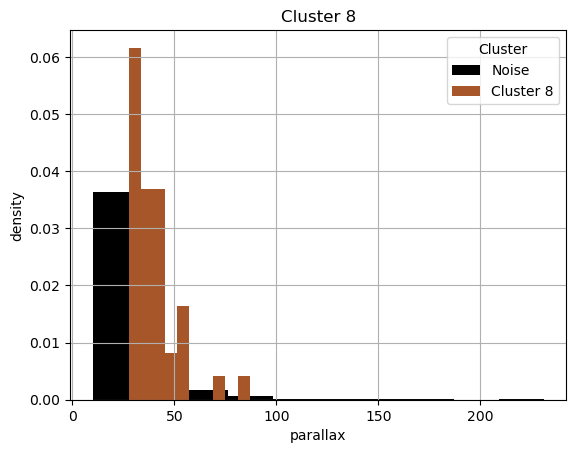

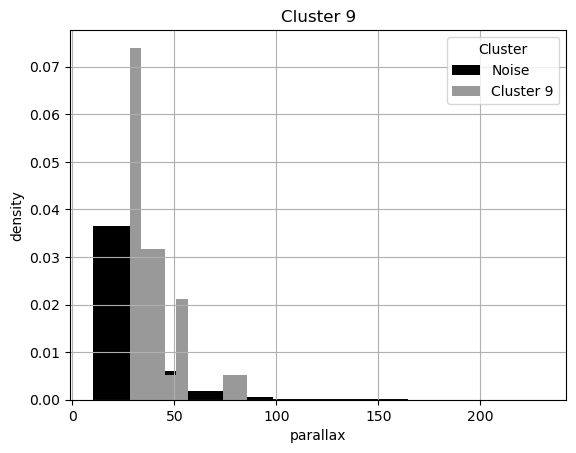

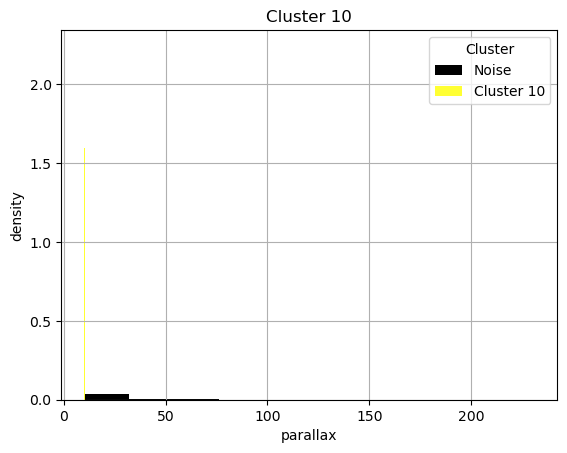

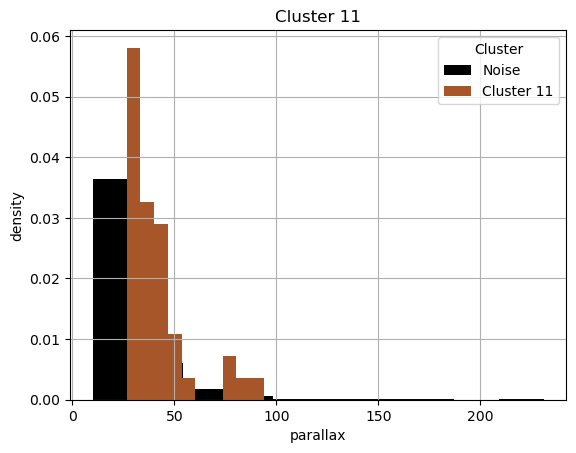

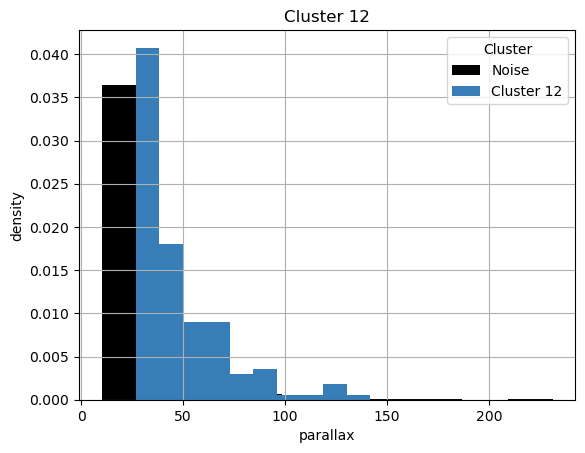

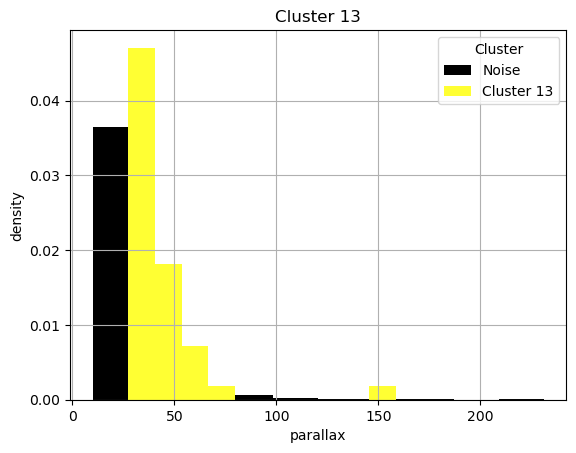

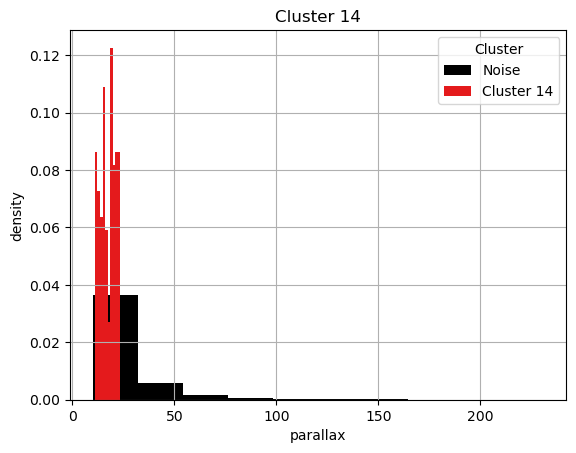

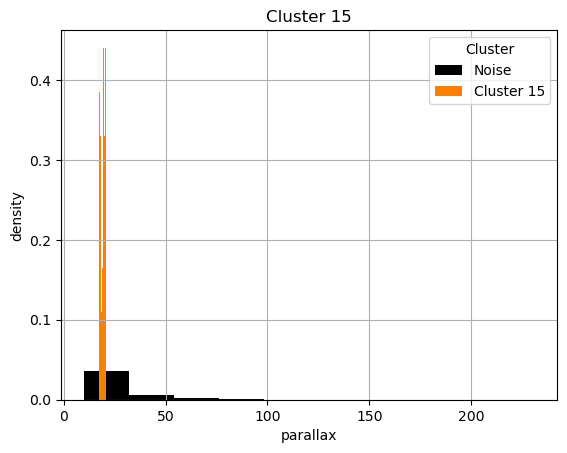

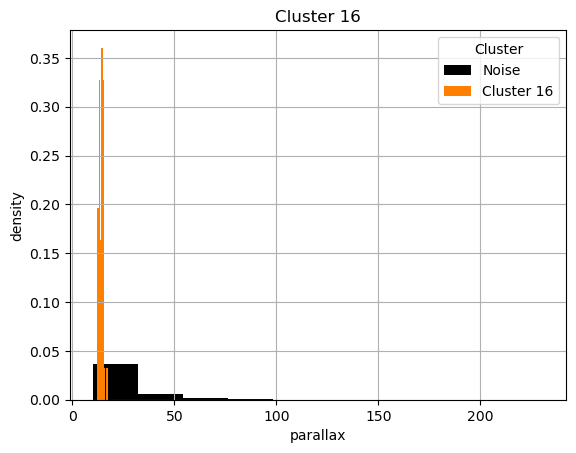

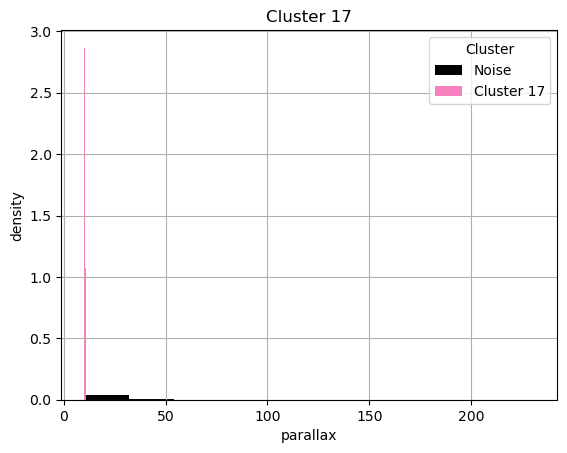

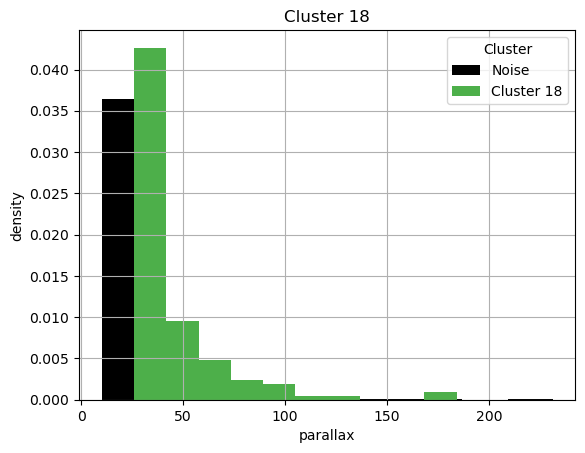

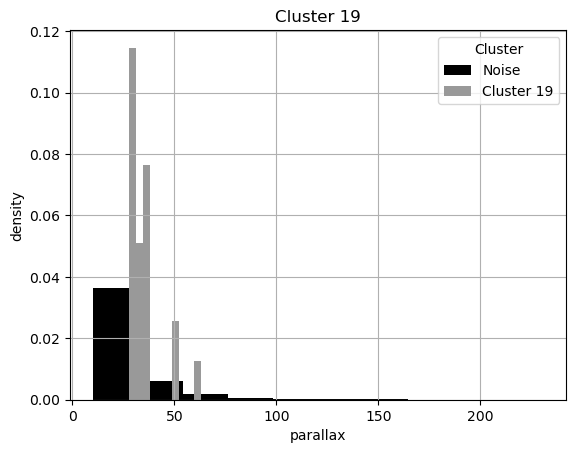

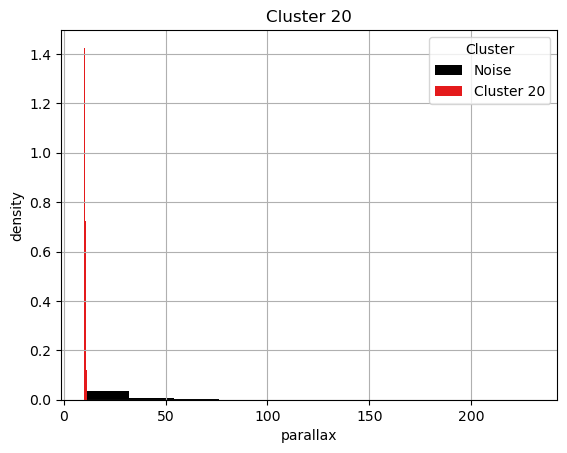

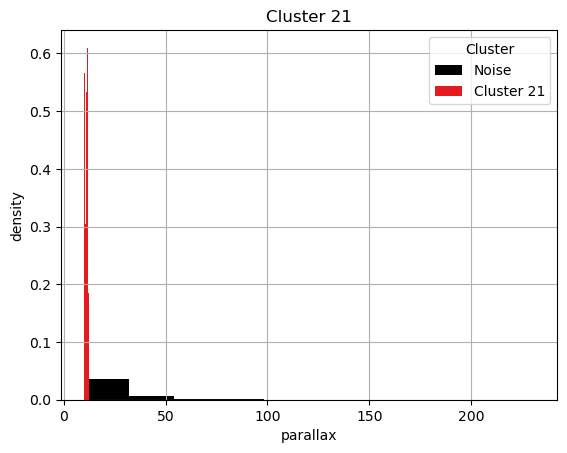

In [63]:
for cluster in clusters:
    subset = dff[dff['cluster'] == cluster]
    plt.hist(df['parallax'], color='k', label='Noise', density = True)
    plt.hist(subset['parallax'],color=[color_dict[cluster]],
                label=f'Cluster {cluster}', density=True)

    plt.xlabel('parallax')
    plt.ylabel('density')
    plt.title(f'Cluster {cluster}')
    plt.legend(title='Cluster')
    plt.grid(True)
#     plt.savefig(f"ruta_imagenes_evolucion/diagramas_cm/diagrama_cluster_{cluster}.png")
    plt.show()

(array([  2.,   2.,   6.,   3.,   4.,   4.,  10.,  12.,   5.,  17.,  11.,
         16.,  10.,  18.,  20.,  21.,  16.,  21.,  14.,  25.,  23.,  24.,
         15.,  24.,  18.,  26.,  32.,  28.,  35.,  42.,  36.,  46.,  26.,
         42.,  21.,   8.,   1.,   0.,   1.,   6.,   8.,  13.,  20.,  10.,
         10.,  11.,  17.,  20.,  19.,   6.,  25.,  11.,  13.,   5.,   9.,
          6.,   2.,   2.,   3.,   4.,   9.,   3.,   8.,  12.,   8.,   5.,
          9.,   6.,   8.,   8.,   7.,   4.,  10.,   9.,  14.,  14.,  11.,
         19.,   8.,  17.,  24.,  33.,  21.,  47.,  50.,  50.,  37.,  43.,
         55.,  39.,  33.,  35.,  64.,  70.,  72.,  96., 113.,  79.,  71.,
         77.]),
 array([ 4.32678479,  5.28347493,  6.24016508,  7.19685523,  8.15354537,
         9.11023552, 10.06692567, 11.02361582, 11.98030596, 12.93699611,
        13.89368626, 14.8503764 , 15.80706655, 16.7637567 , 17.72044685,
        18.67713699, 19.63382714, 20.59051729, 21.54720743, 22.50389758,
        23.46058773, 24.41

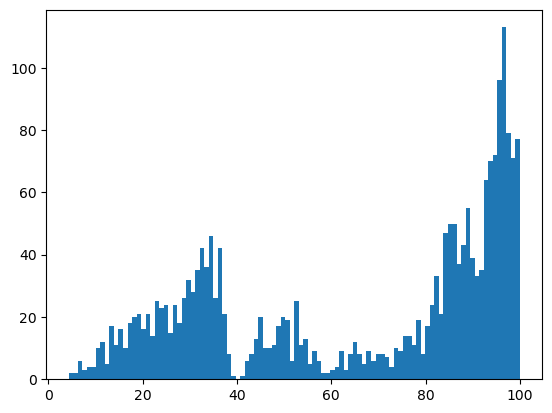

In [64]:
plt.hist(1000/df['parallax'], bins=100)

In [65]:
(1000/df['parallax']).describe()

count    2203.000000
mean       65.919304
std        30.079410
min         4.326785
25%        34.234768
50%        81.095902
75%        93.780918
max        99.995800
Name: parallax, dtype: float64

In [66]:
df_temp = df.groupby(['cluster']).agg({'parallax':'mean','source_id':'count'}).reset_index()
df_temp['distancia'] = 1000/df['parallax']
df_temp[df_temp['distancia']<80]

,cluster,parallax,source_id,distancia


In [67]:
(1000/df[df['cluster']==16]['parallax']).describe()

count    61.000000
mean     70.837688
std       5.261570
min      58.123455
25%      66.967626
50%      69.494752
75%      74.570014
max      81.964043
Name: parallax, dtype: float64

In [103]:
df.groupby(['cluster']).agg({'probabilidad':'median'}).reset_index().sort_values(by=['probabilidad'], ascending=[False])

,cluster,probabilidad
19,18,0.80250
13,12,0.80250
6,5,0.79500
8,7,0.79375
17,16,0.79250
15,14,0.78000
9,8,0.77750
14,13,0.77500
1,0,0.77500
10,9,0.77500
